<a href="https://colab.research.google.com/github/japenped/Lab_GE234_Kwandao/blob/main/Lab5_GE234_Rasterio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [1]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "/content/sample.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)


ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 1001, 'height': 1001, 'count': 3, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]'), 'transform': Affine(10.0, 0.0, 590520.0,
       0.0, -10.0, 5790630.0)}



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


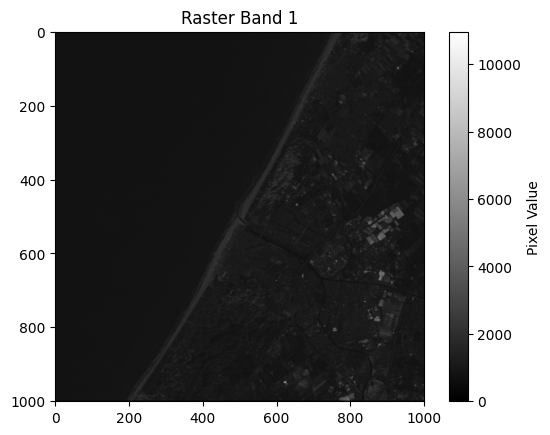

In [2]:
import rasterio
import matplotlib.pyplot as plt

# กำหนด path ของไฟล์ Raster
raster_path = "/content/sample.tif" # ต้องกำหนด raster_path อีกครั้งเพื่อให้เซลล์นี้ทำงานได้โดยอิสระ

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()


## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


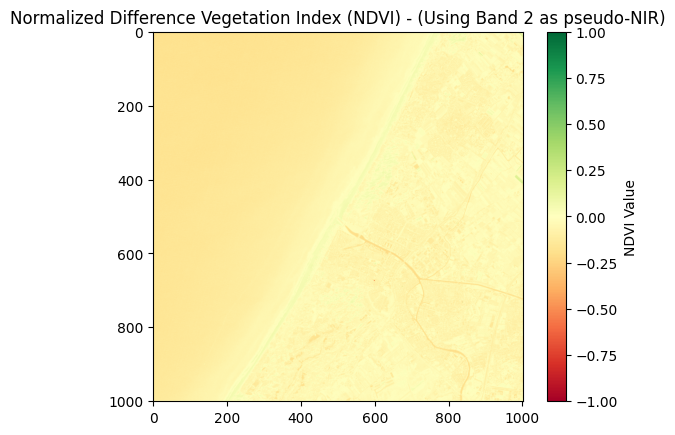

หมายเหตุ: ไฟล์ 'sample.tif' มีเพียง 3 แบนด์เท่านั้น การคำนวณนี้ใช้แบนด์ 2 เป็นค่า 'pseudo-NIR' และแบนด์ 1 เป็น 'Red' เพื่อสาธิตการทำงาน ซึ่งอาจไม่ใช่ค่า NDVI มาตรฐานที่ถูกต้องหากไม่มีแบนด์ NIR จริง


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    # The original image 'sample.tif' has only 3 bands.
    # A true NDVI requires a Near-Infrared (NIR) band (typically Band 4).
    # To fix the IndexError, we will use Band 2 as an approximation for NIR
    # and Band 1 for Red, acknowledging this is not a standard NDVI.
    # Band 1: Red (approx.)
    # Band 2: Green (approx. pseudo-NIR for demonstration)
    # Band 3: Blue (approx.)

    # Read Band 2 as 'NIR' (for demonstration only) and Band 1 as 'Red'
    nir = dataset.read(2).astype(float)  # ใช้ Band 2 เป็น 'pseudo-NIR' สำหรับการสาธิต
    red = dataset.read(1).astype(float)  # ใช้ Band 1 เป็น 'Red' สำหรับการสาธิต

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI) - (Using Band 2 as pseudo-NIR)")
plt.show()

print("หมายเหตุ: ไฟล์ 'sample.tif' มีเพียง 3 แบนด์เท่านั้น การคำนวณนี้ใช้แบนด์ 2 เป็นค่า 'pseudo-NIR' และแบนด์ 1 เป็น 'Red' เพื่อสาธิตการทำงาน ซึ่งอาจไม่ใช่ค่า NDVI มาตรฐานที่ถูกต้องหากไม่มีแบนด์ NIR จริง")


## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [5]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")


บันทึกไฟล์ NDVI เรียบร้อย!



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [11]:
import rasterio
from rasterio.mask import mask
import fiona
import json

# --- เพิ่มส่วนนี้เพื่อสร้างไฟล์ boundary.json หากยังไม่มี ---
# ตรวจสอบว่ามีไฟล์ boundary.json หรือไม่ ถ้าไม่มีให้สร้างขึ้นมา
try:
    with open("boundary.json", "r") as f:
        pass # File exists, do nothing
except FileNotFoundError:
    # สร้างข้อมูล Polygon อย่างง่ายสำหรับไฟล์ boundary.json
    # พิกัดนี้อยู่ในขอบเขตของ sample.tif โดยประมาณ
    polygon_coords = [
        [
            [591000.0, 5790000.0],
            [592000.0, 5790000.0],
            [592000.0, 5789000.0],
            [591000.0, 5789000.0],
            [591000.0, 5790000.0]
        ]
    ]

    geojson_feature = {
        "type": "FeatureCollection",
        "features": [
            {
                "type": "Feature",
                "properties": {},
                "geometry": {
                    "type": "Polygon",
                    "coordinates": polygon_coords
                }
            }
        ]
    }

    with open("boundary.json", "w") as f:
        json.dump(geojson_feature, f)
    print("สร้างไฟล์ boundary.json จำลองขึ้นมาแล้วสำหรับสาธิต.")
# ---------------------------------------------------------

# 1. เปิดไฟล์ขอบเขต (ไฟล์ที่เราสร้างหรือโหลดมา)
with fiona.open("boundary.json", "r") as shapefile:
    shapes = [feature["geometry"] for feature in shapefile]

# 2. เปิดไฟล์ภาพ Raster จาก URL
raster_path = "/content/sample.tif"

with rasterio.open(raster_path) as src:
    # ตัดภาพโดยใช้ขอบเขตจาก shapefile
    out_image, out_transform = mask(src, shapes, crop=True)
    out_meta = src.meta.copy()

    # อัปเดตข้อมูลเมตาให้ตรงกับภาพที่ถูกตัดใหม่
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

# 3. บันทึกผลลัพธ์ลงเครื่อง
with rasterio.open("clipped_landsat.tif", "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดภาพและบันทึกไฟล์เป็น clipped_landsat.tif เรียบร้อยแล้ว!")

สร้างไฟล์ boundary.json จำลองขึ้นมาแล้วสำหรับสาธิต.
ตัดภาพและบันทึกไฟล์เป็น clipped_landsat.tif เรียบร้อยแล้ว!



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


**แบบฝึกหัด 1**: ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib

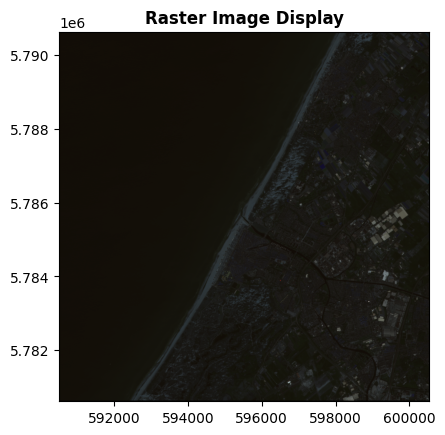

<Axes: title={'center': 'Raster Image Display'}>

In [2]:
import rasterio
from rasterio.plot import show

# 1. เปิดไฟล์ Raster
dataset = rasterio.open('/content/sample.tif')

# 2. แสดงผลภาพ
show(dataset, title='Raster Image Display')


**แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้

In [3]:
import rasterio

# เปิดไฟล์ Raster
with rasterio.open('/content/sample.tif') as src:
    # 1. ดึง Metadata ทั้งหมดเป็น Dictionary
    meta = src.meta
    print("--- Full Metadata ---")
    print(meta)

    print("\n--- Key Information ---")
    print(f"จำนวนแบนด์ (Count): {src.count}")
    print(f"ความกว้าง (Width): {src.width} pixels")
    print(f"ความสูง (Height): {src.height} pixels")
    print(f"ระบบพิกัด (CRS): {src.crs}")
    print(f"ค่าพิกัดขอบเขต (Bounds): {src.bounds}")
    print(f"ชนิดข้อมูล (Dtype): {src.dtypes[0]}")
    print(f"การแปลงพิกัด (Transform):\n{src.transform}")


--- Full Metadata ---
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 1001, 'height': 1001, 'count': 3, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]'), 'transform': Affine(10.0, 0.0, 590520.0,
       0.0, -10.0, 5790630.0)}

--- Key Information ---
จำนวนแบนด์ (Count): 3
ความกว้าง (Width): 1001 pixels
ความสูง (Height): 1001 pixels
ระบบพิกัด (CRS): EPSG:32631
ค่าพิกัดขอบเขต (Bounds): BoundingBox(left=590520.0,

**แบบฝึกหัด 3**: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่

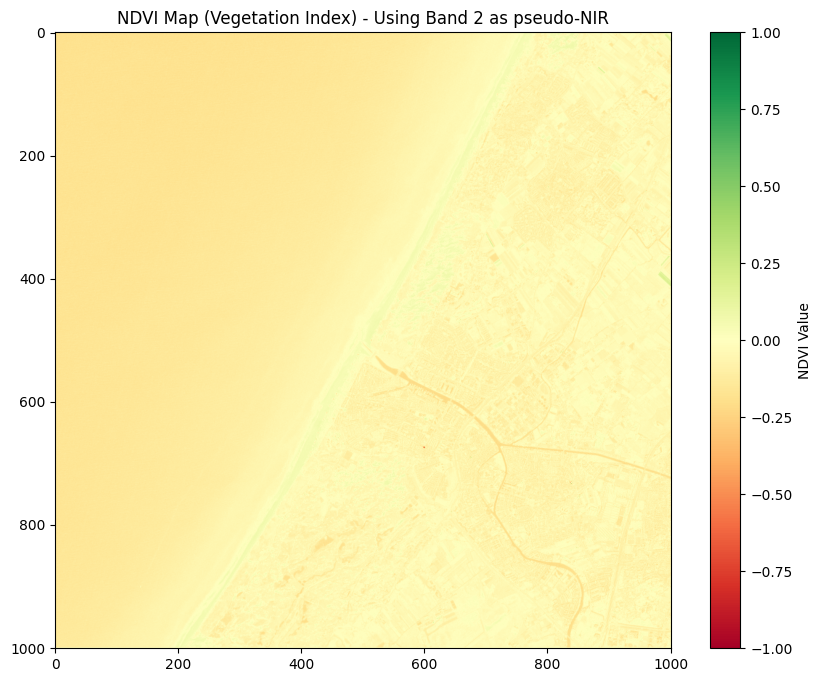

หมายเหตุ: ไฟล์ 'sample.tif' มีเพียง 3 แบนด์เท่านั้น การคำนวณนี้ใช้แบนด์ 2 เป็นค่า 'pseudo-NIR' และแบนด์ 1 เป็น 'Red' เพื่อสาธิตการทำงาน ซึ่งอาจไม่ใช่ค่า NDVI มาตรฐานที่ถูกต้องหากไม่มีแบนด์ NIR จริง


In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# 1. เปิดไฟล์และอ่านข้อมูลแบนด์ที่ต้องการ
# The original image 'sample.tif' has only 3 bands.
# A true NDVI requires a Near-Infrared (NIR) band (typically Band 4).
# To fix the IndexError, we will use Band 2 as an approximation for NIR
# and Band 1 for Red, acknowledging this is not a standard NDVI.
# Band 1: Red (approx.)
# Band 2: Green (approx. pseudo-NIR for demonstration)
# Band 3: Blue (approx.)
with rasterio.open('/content/sample.tif') as src:
    red = src.read(1).astype('float32') # ใช้ Band 1 เป็น Red
    nir = src.read(2).astype('float32') # ใช้ Band 2 เป็น pseudo-NIR สำหรับการสาธิต

# 2. คำนวณค่า NDVI
# ใช้ np.seterr เพื่อจัดการกรณีหารด้วยศูนย์ (ถ้ามีพิกเซลว่าง)
np.seterr(divide='ignore', invalid='ignore')
ndvi = (nir - red) / (nir + red + 1e-10) # เพิ่ม 1e-10 เพื่อหลีกเลี่ยงการหารด้วยศูนย์

# 3. แสดงผลด้วย Matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1) # กำหนด vmin, vmax เพื่อให้สเกลสีถูกต้อง
plt.colorbar(label='NDVI Value')
plt.title('NDVI Map (Vegetation Index) - Using Band 2 as pseudo-NIR')
plt.show()

print("หมายเหตุ: ไฟล์ 'sample.tif' มีเพียง 3 แบนด์เท่านั้น การคำนวณนี้ใช้แบนด์ 2 เป็นค่า 'pseudo-NIR' และแบนด์ 1 เป็น 'Red' เพื่อสาธิตการทำงาน ซึ่งอาจไม่ใช่ค่า NDVI มาตรฐานที่ถูกต้องหากไม่มีแบนด์ NIR จริง")

**แบบฝึกหัด 4**: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile

In [9]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd

# 1. อ่านไฟล์ Shapefile (ขอบเขตที่ต้องการตัด)
# แนะนำให้ใช้ GeoPandas เพราะจัดการระบบพิกัด (CRS) ได้ง่าย
aoi = gpd.read_file('boundary.json') # ใช้ boundary.json ที่สร้างไว้ก่อนหน้า

# 2. เปิดไฟล์ Raster ต้นฉบับ
with rasterio.open('/content/sample.tif') as src:
    # **ข้อควรระวัง**: ต้องแปลงพิกัดของ Shapefile ให้ตรงกับ Raster ก่อนตัด
    # แก้ไข: ใช้ set_crs เพื่อระบุว่าพิกัดใน aoi อยู่ในระบบเดียวกับ src.crs อยู่แล้ว
    # ไม่ใช่การ reproject
    aoi = aoi.set_crs(src.crs, allow_override=True)

    # ดึง Geometry ของ Shapefile ออกมาในรูปแบบที่ Rasterio เข้าใจ
    shapes = aoi.geometry

    # 3. สั่งตัดภาพ
    # crop=True จะทำให้ขนาดของ Array ใหม่เล็กลงเท่ากับขอบเขตของ Shapefile
    out_image, out_transform = mask(src, shapes, crop=True)

    # คัดลอก Metadata เดิมมาปรับปรุงค่าใหม่ (ขนาด และ Transform)
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

# 4. บันทึกภาพที่ตัดแล้วลงไฟล์ใหม่
with rasterio.open("clipped_raster.tif", "w", **out_meta) as dest:
    dest.write(out_image)

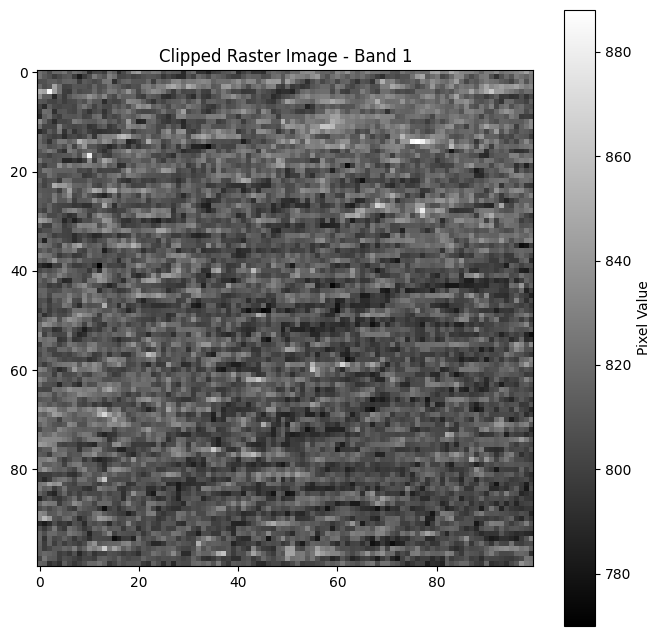

แสดงภาพ clipped_raster.tif เรียบร้อยแล้ว!


In [11]:
import rasterio
import matplotlib.pyplot as plt
from rasterio.plot import show

# เปิดไฟล์ Raster ที่ถูกตัดแล้ว
clipped_raster_path = "clipped_raster.tif"
with rasterio.open(clipped_raster_path) as src:
    # อ่านแบนด์แรกของภาพ
    band1_clipped = src.read(1)

    # แสดงผลภาพ
    plt.figure(figsize=(8, 8))
    # แก้ไข: ใช้ plt.imshow โดยตรงและเก็บ mappable object
    mappable = plt.imshow(band1_clipped, cmap='gray')
    plt.title('Clipped Raster Image - Band 1') # ตั้งชื่อเรื่องโดยตรงกับ plt
    plt.colorbar(mappable, label='Pixel Value') # ส่ง mappable ไปยัง colorbar
    plt.show()

print(f"แสดงภาพ {clipped_raster_path} เรียบร้อยแล้ว!")